In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [3]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [13]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [4]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,
random_state=42)

In [6]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [7]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)

In [8]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

In [9]:
ridge=Ridge(alpha=1.0)
ridge.fit(X_train_scaled,y_train)
ridge_pred=ridge.predict(X_test_scaled)

In [10]:
lasso=Lasso(alpha=0.1)
lasso.fit(X_train_scaled,y_train)
lasso_pred=lasso.predict(X_test_scaled)

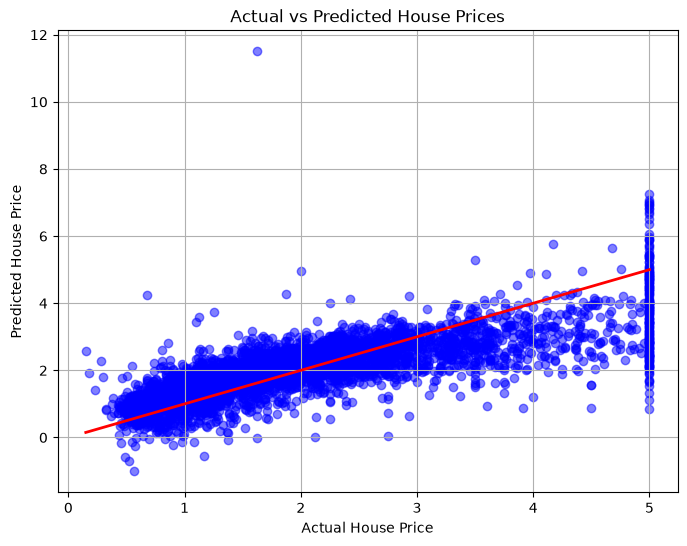

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted values
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)

# Ideal prediction line (45-degree line)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)

plt.show()

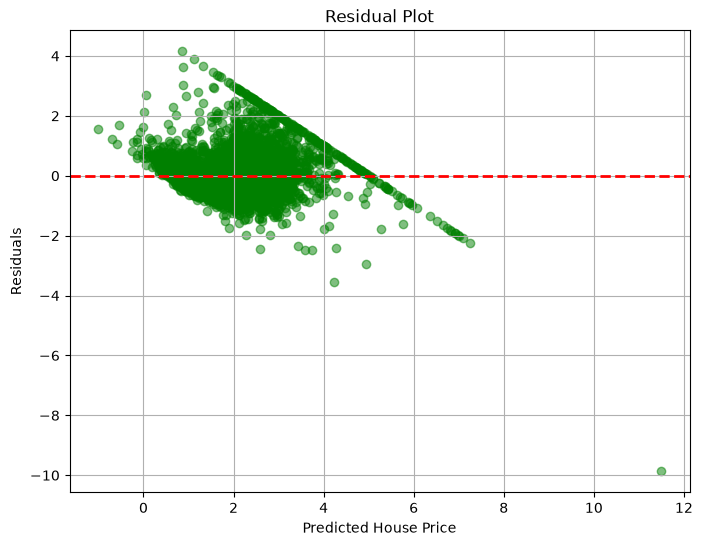

In [16]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

# Scatter plot of predicted values vs residuals
plt.scatter(y_pred, residuals, color='green', alpha=0.5)

# Horizontal line at zero residual
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)

plt.show()

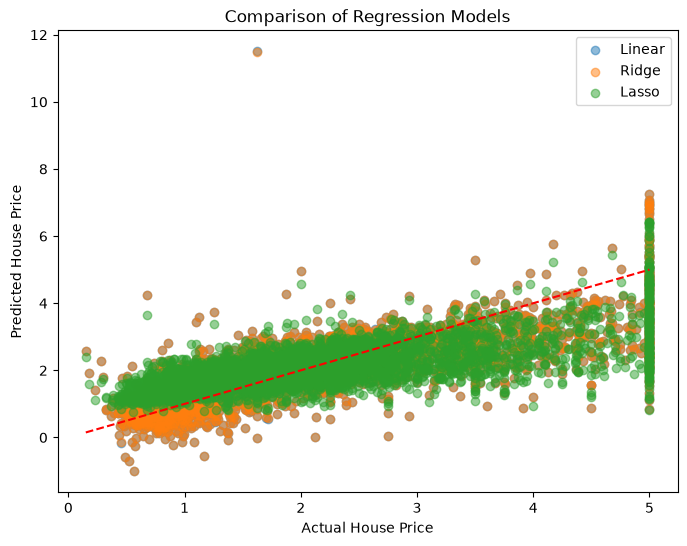

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Linear Regression predictions
plt.scatter(y_test, y_pred, alpha=0.5, label="Linear")

# Ridge Regression predictions
plt.scatter(y_test, ridge_pred, alpha=0.5, label="Ridge")

# Lasso Regression predictions
plt.scatter(y_test, lasso_pred, alpha=0.5, label="Lasso")

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Comparison of Regression Models")
plt.legend()

plt.show()